# Advanced Ensemble Learning and Evaluation for Cancer Prediction

**Dataset:** `sklearn.datasets.load_breast_cancer`

This notebook implements a rigorous, end-to-end machine learning pipeline with an emphasis on
**ensemble methods**, **hyperparameter tuning**, and **statistical evaluation**.

| Phase | Contents |
|-------|----------|
| **A** | Data preparation, integrity checking, correlation-based feature selection (top 5), feature scaling |
| **B** | Decision Tree (baseline), Gradient Boosting (advanced ensemble), SVM-RBF — all tuned with `GridSearchCV` |
| **C** | Hyperparameter impact curves, model comparison matrix, annotated confusion-matrix heatmap |



## 0. Environment setup

All imports are collected here so the notebook's dependencies are declared in one place.

In [ ]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, validation_curve,
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)

RANDOM_STATE = 42
POS_LABEL    = 0
FIG_DIR      = "figures"

os.makedirs(FIG_DIR, exist_ok=True)

# Consistent, readable plot styling across every figure
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"]  = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["savefig.bbox"] = "tight"

print("Environment ready. Figures will be saved to ./%s/" % FIG_DIR)

Environment ready. Figures will be saved to ./figures/


In [ ]:
bunch = load_breast_cancer()

print("Raw object type :", type(bunch).__name__)
print("Available keys  :", list(bunch.keys()))
print("Feature count   :", len(bunch.feature_names))
print("Sample count    :", bunch.data.shape[0])

Raw object type : Bunch
Available keys  : ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']
Feature count   : 30
Sample count    : 569


In [ ]:
df = pd.DataFrame(data=bunch.data, columns=bunch.feature_names)

df["target"] = bunch.target

TARGET_MAP = {i: name for i, name in enumerate(bunch.target_names)}
df["diagnosis"] = df["target"].map(TARGET_MAP)

print("Explicit target mapping:", TARGET_MAP)
print("DataFrame shape       :", df.shape)
df.head()

Explicit target mapping: {0: np.str_('malignant'), 1: np.str_('benign')}
DataFrame shape       : (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [ ]:
feature_cols = list(bunch.feature_names)
audit_cols   = feature_cols + ["target"]

null_counts    = df[audit_cols].isnull().sum()
total_nulls    = int(null_counts.sum())
n_duplicates   = int(df.duplicated().sum())
n_non_finite   = int((~np.isfinite(df[feature_cols].values)).sum())

print("=" * 62)
print("DATA INTEGRITY REPORT")
print("=" * 62)

# --- Conditional log: missing values --------------------------------------
if total_nulls > 0:
    print(f"[WARNING] {total_nulls} missing value(s) detected across "
          f"{int((null_counts > 0).sum())} column(s):")
    print(null_counts[null_counts > 0].to_string())
    print("          -> Imputation required before modelling.")
else:
    print(f"[OK]      No missing values found across all "
          f"{len(audit_cols)} dimensions ({df.shape[0]} rows checked).")

# --- Conditional log: non-finite values -----------------------------------
if n_non_finite > 0:
    print(f"[WARNING] {n_non_finite} non-finite (inf/-inf) value(s) detected.")
else:
    print("[OK]      All feature values are finite.")

# --- Conditional log: duplicates ------------------------------------------
if n_duplicates > 0:
    print(f"[WARNING] {n_duplicates} duplicate row(s) detected -> consider de-duplication.")
else:
    print("[OK]      No duplicate rows detected.")

print("=" * 62)
print("Verdict:", "DATASET IS CLEAN - proceeding to feature selection."
      if (total_nulls == n_duplicates == n_non_finite == 0)
      else "DATASET REQUIRES CLEANING.")

DATA INTEGRITY REPORT
[OK]      No missing values found across all 31 dimensions (569 rows checked).
[OK]      All feature values are finite.
[OK]      No duplicate rows detected.
Verdict: DATASET IS CLEAN - proceeding to feature selection.


In [ ]:
non_numeric = df[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print("[WARNING] Non-numeric feature columns:", non_numeric)
else:
    print(f"[OK]      All {len(feature_cols)} feature columns are numeric (float64).")

[OK]      All 30 feature columns are numeric (float64).


In [ ]:
corr_with_target = df[feature_cols + ["target"]].corr()["target"].drop("target")

# Rank by strength (absolute value), keep direction for interpretation
corr_ranked = corr_with_target.reindex(
    corr_with_target.abs().sort_values(ascending=False).index
)

TOP_K = 5
selected_features = corr_ranked.head(TOP_K).index.tolist()

print(f"Top {TOP_K} features by |correlation| with diagnosis:\n")
summary = pd.DataFrame({
    "correlation":  corr_ranked.head(TOP_K).round(4),
    "abs_corr":     corr_ranked.head(TOP_K).abs().round(4),
    "variance":     df[selected_features].var().round(4),
    "interpretation": ["higher -> benign" if v > 0 else "higher -> malignant"
                       for v in corr_ranked.head(TOP_K)],
})
summary

Top 5 features by |correlation| with diagnosis:



,correlation,abs_corr,variance,interpretation
worst concave points,-0.7936,0.7936,0.0043,higher -> malignant
worst perimeter,-0.7829,0.7829,1129.1308,higher -> malignant
mean concave points,-0.7766,0.7766,0.0015,higher -> malignant
worst radius,-0.7765,0.7765,23.3602,higher -> malignant
mean perimeter,-0.7426,0.7426,590.4405,higher -> malignant


In [ ]:
variances = df[selected_features].var()
if (variances <= 1e-8).any():
    print("[WARNING] Near-constant feature(s) selected:",
          variances[variances <= 1e-8].index.tolist())
else:
    print(f"[OK] All {TOP_K} selected features carry meaningful variance "
          f"(min variance = {variances.min():.4f}).")

print("\nSelected feature subset:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i}. {f}")

[OK] All 5 selected features carry meaningful variance (min variance = 0.0015).

Selected feature subset:
  1. worst concave points
  2. worst perimeter
  3. mean concave points
  4. worst radius
  5. mean perimeter


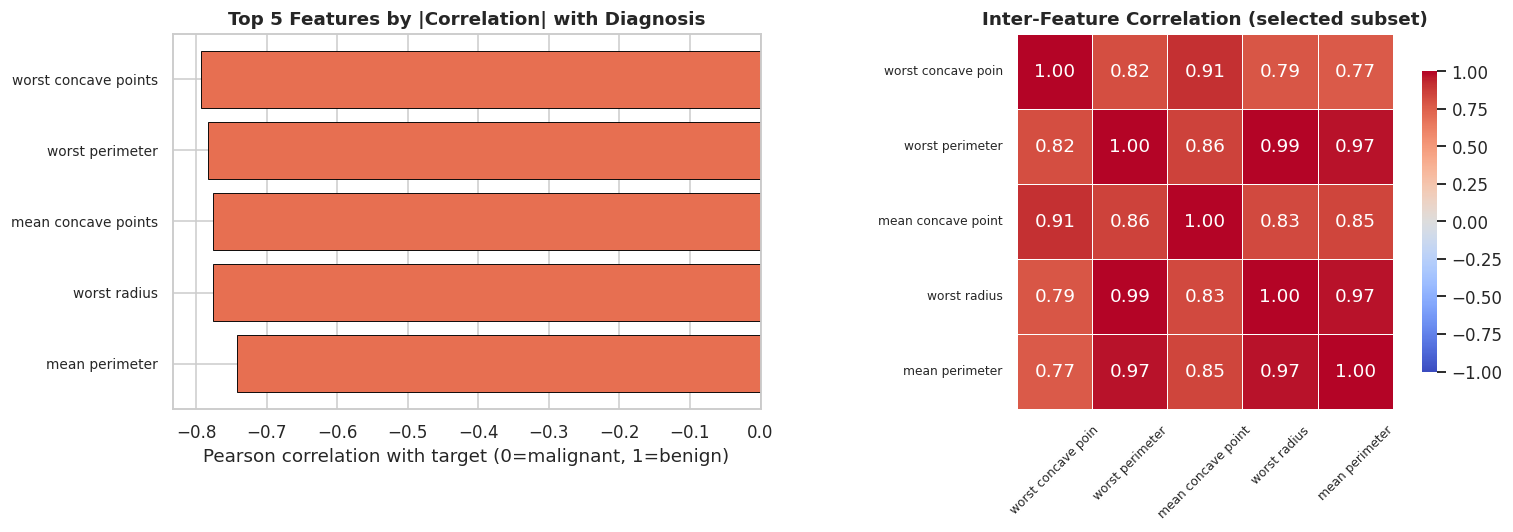

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#2a9d8f" if v > 0 else "#e76f51" for v in corr_ranked.head(TOP_K)]
axes[0].barh(range(TOP_K), corr_ranked.head(TOP_K).values[::-1],
             color=colors[::-1], edgecolor="black", linewidth=0.6)
axes[0].set_yticks(range(TOP_K))
axes[0].set_yticklabels(selected_features[::-1], fontsize=9)
axes[0].axvline(0, color="black", linewidth=0.9)
axes[0].set_xlabel("Pearson correlation with target (0=malignant, 1=benign)")
axes[0].set_title("Top 5 Features by |Correlation| with Diagnosis", fontweight="bold")

subset_corr = df[selected_features].corr()
sns.heatmap(subset_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=axes[1],
            xticklabels=[f[:18] for f in selected_features],
            yticklabels=[f[:18] for f in selected_features])
axes[1].set_title("Inter-Feature Correlation (selected subset)", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].tick_params(axis="y", rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_feature_selection.png"))
plt.show()

In [ ]:
# --- Restrict to the selected feature subset ------------------------------
X = df[selected_features].copy()
y = df["target"].copy()

# --- Stratified split BEFORE any scaling ----------------------------------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,              # preserve class proportions
)

print(f"Training set: {X_train_raw.shape[0]} samples x {X_train_raw.shape[1]} features")
print(f"Test set    : {X_test_raw.shape[0]} samples x {X_test_raw.shape[1]} features")
print(f"\nTrain class balance: {dict(y_train.value_counts().rename(TARGET_MAP))}")
print(f"Test  class balance: {dict(y_test.value_counts().rename(TARGET_MAP))}")

Training set: 426 samples x 5 features
Test set    : 143 samples x 5 features

Train class balance: {np.str_('benign'): np.int64(267), np.str_('malignant'): np.int64(159)}
Test  class balance: {np.str_('benign'): np.int64(90), np.str_('malignant'): np.int64(53)}


In [ ]:
# --- StandardScaler: zero mean, unit variance -----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)   # FIT on training data only
X_test  = scaler.transform(X_test_raw)        # APPLY the same transform to test

# Verify the transformation achieved zero mean / unit variance on the training set
scaling_check = pd.DataFrame({
    "feature":      selected_features,
    "raw_mean":     X_train_raw.mean().values.round(3),
    "raw_std":      X_train_raw.std().values.round(3),
    "scaled_mean":  X_train.mean(axis=0).round(6),
    "scaled_std":   X_train.std(axis=0).round(6),
})
print("Scaling verification (training set):")
scaling_check

Scaling verification (training set):


,feature,raw_mean,raw_std,scaled_mean,scaled_std
0,worst concave points,0.114,0.067,-0.0,1.0
1,worst perimeter,106.804,33.449,0.0,1.0
2,mean concave points,0.048,0.039,0.0,1.0
3,worst radius,16.203,4.808,-0.0,1.0
4,mean perimeter,91.593,24.185,-0.0,1.0


---
# Phase B — Model Implementation & Hyperparameter Tuning

We implement three architecturally distinct classifiers and optimise each with `GridSearchCV`
over a **stratified 5-fold cross-validation** on the training set. The test set is untouched
during tuning and used exactly once, for final evaluation.

**Scoring choice.** We optimise for **F1 on the malignant class** rather than accuracy. With mild
class imbalance and an asymmetric error cost (a missed cancer is worse than a false alarm), F1 on
the positive class is the more faithful objective.

In [ ]:
# --- Shared cross-validation strategy -------------------------------------
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Custom scorer: F1 measured on the MALIGNANT class (label 0)
from sklearn.metrics import make_scorer
f1_malignant = make_scorer(f1_score, pos_label=POS_LABEL)

print("CV strategy   : Stratified 5-fold (shuffled, seed=%d)" % RANDOM_STATE)
print("Tuning metric : F1-score on the malignant class")

CV strategy   : Stratified 5-fold (shuffled, seed=42)
Tuning metric : F1-score on the malignant class


In [ ]:
dt_param_grid = {
    "max_depth":         [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_leaf":  [1, 2, 4, 8],
    "criterion":         ["gini", "entropy"],
}

dt_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=dt_param_grid,
    scoring=f1_malignant,
    cv=cv_strategy,
    n_jobs=-1,
    return_train_score=True,
)
dt_search.fit(X_train, y_train)

print("DECISION TREE (baseline)")
print("  Best params   :", dt_search.best_params_)
print(f"  Best CV F1    : {dt_search.best_score_:.4f}")
print(f"  Combinations  : {len(dt_search.cv_results_['params'])}")

DECISION TREE (baseline)
  Best params   : {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1}
  Best CV F1    : 0.9332
  Combinations  : 64


## B.2  Gradient Boosting Classifier — advanced boosting ensemble

Gradient Boosting builds trees **sequentially**, each one fitting the residual errors of the
ensemble so far. This is the key architectural contrast with the baseline: instead of one tree
trying to explain everything, many shallow trees each correct their predecessors' mistakes.

The critical tuning tension is between `n_estimators` (how many corrective stages) and
`learning_rate` (how much each stage contributes) — they trade off directly against each other.

In [ ]:
gb_param_grid = {
    "n_estimators":   [50, 100, 200, 300],
    "learning_rate":  [0.01, 0.05, 0.1, 0.2],
    "max_depth":      [2, 3, 4],
    "subsample":      [0.8, 1.0],
}

gb_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=gb_param_grid,
    scoring=f1_malignant,
    cv=cv_strategy,
    n_jobs=-1,
    return_train_score=True,
)
gb_search.fit(X_train, y_train)

print("GRADIENT BOOSTING (advanced ensemble)")
print("  Best params   :", gb_search.best_params_)
print(f"  Best CV F1    : {gb_search.best_score_:.4f}")
print(f"  Combinations  : {len(gb_search.cv_results_['params'])}")

GRADIENT BOOSTING (advanced ensemble)
  Best params   : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
  Best CV F1    : 0.9427
  Combinations  : 96


In [ ]:
svm_param_grid = {
    "C":      [0.1, 1, 10, 100],
    "gamma":  ["scale", "auto", 0.01, 0.1, 1],
    "kernel": ["rbf"],
}

svm_search = GridSearchCV(
    estimator=SVC(probability=True, random_state=RANDOM_STATE),
    param_grid=svm_param_grid,
    scoring=f1_malignant,
    cv=cv_strategy,
    n_jobs=-1,
    return_train_score=True,
)
svm_search.fit(X_train, y_train)

print("SUPPORT VECTOR MACHINE (RBF kernel)")
print("  Best params   :", svm_search.best_params_)
print(f"  Best CV F1    : {svm_search.best_score_:.4f}")
print(f"  Combinations  : {len(svm_search.cv_results_['params'])}")

SUPPORT VECTOR MACHINE (RBF kernel)
  Best params   : {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
  Best CV F1    : 0.9351
  Combinations  : 20


In [ ]:
# Collect the optimised estimators
optimised_models = {
    "Decision Tree":     dt_search.best_estimator_,
    "Gradient Boosting": gb_search.best_estimator_,
    "SVM (RBF)":         svm_search.best_estimator_,
}
searches = {
    "Decision Tree":     dt_search,
    "Gradient Boosting": gb_search,
    "SVM (RBF)":         svm_search,
}

# Binary ground truth in "malignant = 1" form, required for roc_auc_score
y_test_binary = (y_test == POS_LABEL).astype(int)

results   = []
preds     = {}
proba_pos = {}   # predicted probability of the MALIGNANT class

for name, model in optimised_models.items():
    y_pred = model.predict(X_test)
    # Column POS_LABEL of predict_proba is P(malignant)
    p_malignant = model.predict_proba(X_test)[:, POS_LABEL]

    preds[name]     = y_pred
    proba_pos[name] = p_malignant

    results.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=POS_LABEL),
        "Recall":    recall_score(y_test, y_pred, pos_label=POS_LABEL),
        "F1-Score":  f1_score(y_test, y_pred, pos_label=POS_LABEL),
        "ROC-AUC":   roc_auc_score(y_test_binary, p_malignant),
        "CV F1":     searches[name].best_score_,
    })

results_df = pd.DataFrame(results).set_index("Model").round(4)
print("FINAL TEST-SET PERFORMANCE (positive class = malignant)\n")
results_df

FINAL TEST-SET PERFORMANCE (positive class = malignant)



,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV F1
Model,,,,,,
Decision Tree,0.9021,0.8305,0.9245,0.8750,0.9372,0.9332
Gradient Boosting,0.9371,0.9400,0.8868,0.9126,0.9868,0.9427
SVM (RBF),0.9441,0.9245,0.9245,0.9245,0.9916,0.9351


In [ ]:
# --- Select the top-performing model --------------------------------------
# F1 balances precision and recall on the class we care about; ROC-AUC breaks ties.
best_model_name = results_df.sort_values(["F1-Score", "ROC-AUC"], ascending=False).index[0]
best_model      = optimised_models[best_model_name]

print(f"TOP-PERFORMING MODEL: {best_model_name}\n")
print(results_df.loc[best_model_name].to_string())
print("\nHyperparameters:", searches[best_model_name].best_params_)

print("\n" + "=" * 60)
print("Detailed classification report:")
print("=" * 60)
print(classification_report(
    y_test, preds[best_model_name],
    target_names=[TARGET_MAP[0], TARGET_MAP[1]], digits=4,
))

TOP-PERFORMING MODEL: SVM (RBF)

Accuracy     0.9441
Precision    0.9245
Recall       0.9245
F1-Score     0.9245
ROC-AUC      0.9916
CV F1        0.9351

Hyperparameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}

Detailed classification report:
              precision    recall  f1-score   support

   malignant     0.9245    0.9245    0.9245        53
      benign     0.9556    0.9556    0.9556        90

    accuracy                         0.9441       143
   macro avg     0.9400    0.9400    0.9400       143
weighted avg     0.9441    0.9441    0.9441       143



In [ ]:
# --- Generalisation check: CV score vs test score -------------------------
# A large positive gap (CV >> test) would suggest we overfitted the hyperparameter search.
print("Generalisation gap (CV F1 - Test F1):\n")
for name in results_df.index:
    gap = results_df.loc[name, "CV F1"] - results_df.loc[name, "F1-Score"]
    flag = "OK" if abs(gap) < 0.05 else "INVESTIGATE"
    print(f"  {name:<20} CV={results_df.loc[name,'CV F1']:.4f}  "
          f"Test={results_df.loc[name,'F1-Score']:.4f}  gap={gap:+.4f}  [{flag}]")

Generalisation gap (CV F1 - Test F1):

  Decision Tree        CV=0.9332  Test=0.8750  gap=+0.0582  [INVESTIGATE]
  Gradient Boosting    CV=0.9427  Test=0.9126  gap=+0.0301  [OK]
  SVM (RBF)            CV=0.9351  Test=0.9245  gap=+0.0106  [OK]


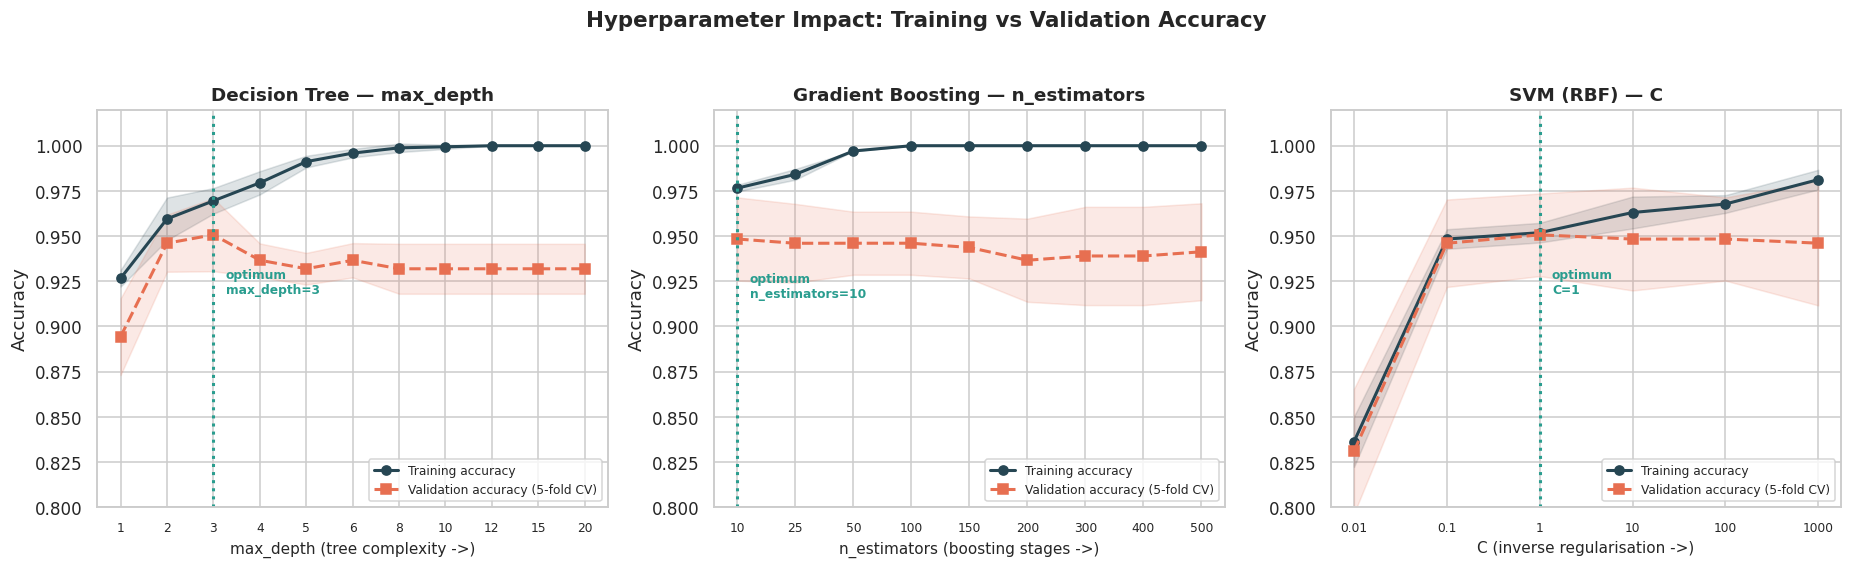

In [ ]:
# --- Sweep definitions: one key hyperparameter per model ------------------
sweeps = [
    {
        "title":      "Decision Tree",
        "estimator":  DecisionTreeClassifier(random_state=RANDOM_STATE),
        "param_name": "max_depth",
        "param_range": [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20],
        "xlabel":     "max_depth (tree complexity ->)",
    },
    {
        "title":      "Gradient Boosting",
        "estimator":  GradientBoostingClassifier(random_state=RANDOM_STATE),
        "param_name": "n_estimators",
        "param_range": [10, 25, 50, 100, 150, 200, 300, 400, 500],
        "xlabel":     "n_estimators (boosting stages ->)",
    },
    {
        "title":      "SVM (RBF)",
        "estimator":  SVC(kernel="rbf", random_state=RANDOM_STATE),
        "param_name": "C",
        "param_range": [0.01, 0.1, 1, 10, 100, 1000],
        "xlabel":     "C (inverse regularisation ->)",
    },
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, sweep in zip(axes, sweeps):
    train_scores, valid_scores = validation_curve(
        estimator=sweep["estimator"],
        X=X_train, y=y_train,
        param_name=sweep["param_name"],
        param_range=sweep["param_range"],
        cv=cv_strategy,
        scoring="accuracy",
        n_jobs=-1,
    )

    # Mean +/- std across the 5 folds
    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    valid_mean, valid_std = valid_scores.mean(axis=1), valid_scores.std(axis=1)

    x_pos    = range(len(sweep["param_range"]))
    log_axis = sweep["param_name"] in ("C", "gamma")

    ax.plot(x_pos, train_mean, "o-", color="#264653", linewidth=2,
            markersize=6, label="Training accuracy")
    ax.fill_between(x_pos, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color="#264653")

    ax.plot(x_pos, valid_mean, "s--", color="#e76f51", linewidth=2,
            markersize=6, label="Validation accuracy (5-fold CV)")
    ax.fill_between(x_pos, valid_mean - valid_std, valid_mean + valid_std,
                    alpha=0.15, color="#e76f51")

    # Mark the validation optimum
    best_idx = int(np.argmax(valid_mean))
    ax.axvline(best_idx, color="#2a9d8f", linestyle=":", linewidth=2)
    ax.annotate(f"optimum\n{sweep['param_name']}={sweep['param_range'][best_idx]}",
                xy=(best_idx, valid_mean[best_idx]),
                xytext=(8, -38), textcoords="offset points",
                fontsize=8, color="#2a9d8f", fontweight="bold",
                ha="left")

    ax.set_xticks(list(x_pos))
    ax.set_xticklabels([str(p) for p in sweep["param_range"]], fontsize=8)
    ax.set_xlabel(sweep["xlabel"], fontsize=10)
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{sweep['title']} — {sweep['param_name']}", fontweight="bold")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_ylim(0.80, 1.02)

fig.suptitle("Hyperparameter Impact: Training vs Validation Accuracy",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_hyperparameter_impact.png"))
plt.show()

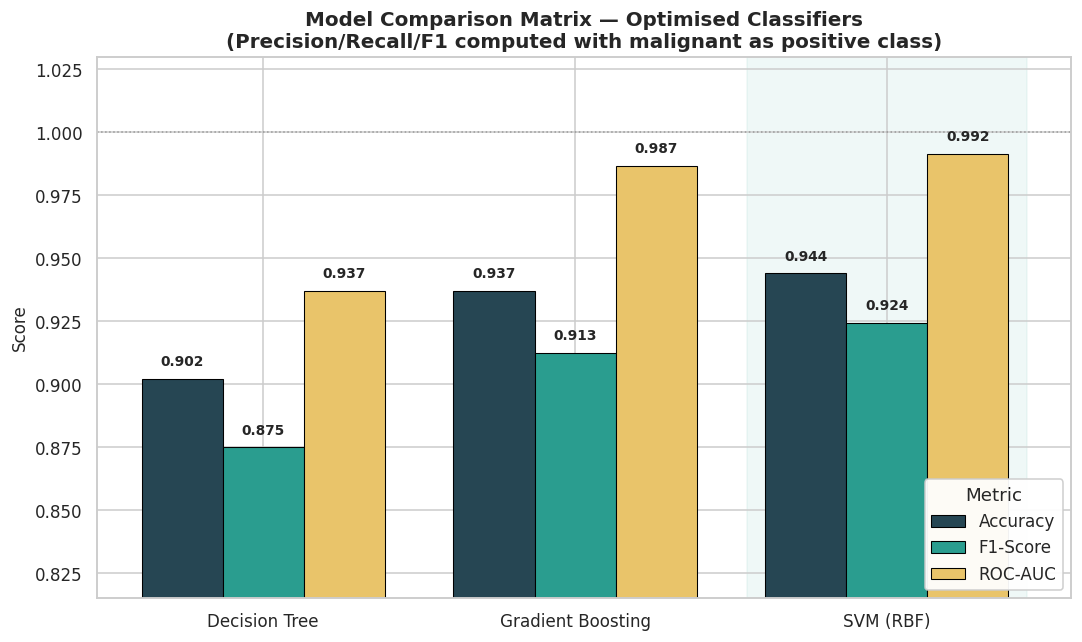

Shaded band marks the top performer: SVM (RBF)


In [ ]:
comparison_metrics = ["Accuracy", "F1-Score", "ROC-AUC"]
model_names = results_df.index.tolist()

x     = np.arange(len(model_names))
width = 0.26
palette = {"Accuracy": "#264653", "F1-Score": "#2a9d8f", "ROC-AUC": "#e9c46a"}

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(comparison_metrics):
    values = results_df[metric].values
    offset = (i - 1) * width
    bars = ax.bar(x + offset, values, width,
                  label=metric, color=palette[metric],
                  edgecolor="black", linewidth=0.7)
    # Value labels on top of each bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.004,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Model Comparison Matrix — Optimised Classifiers\n"
             "(Precision/Recall/F1 computed with malignant as positive class)",
             fontsize=13, fontweight="bold")
ax.legend(title="Metric", loc="lower right", framealpha=0.95)

# Zoomed y-axis so the differences between strong models remain visible
y_floor = max(0.0, results_df[comparison_metrics].values.min() - 0.06)
ax.set_ylim(y_floor, 1.03)
ax.axhline(1.0, color="grey", linestyle=":", linewidth=1, alpha=0.7)

# Highlight the winning model
best_pos = model_names.index(best_model_name)
ax.axvspan(best_pos - 0.45, best_pos + 0.45, color="#2a9d8f", alpha=0.07, zorder=0)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_model_comparison.png"))
plt.show()

print(f"Shaded band marks the top performer: {best_model_name}")

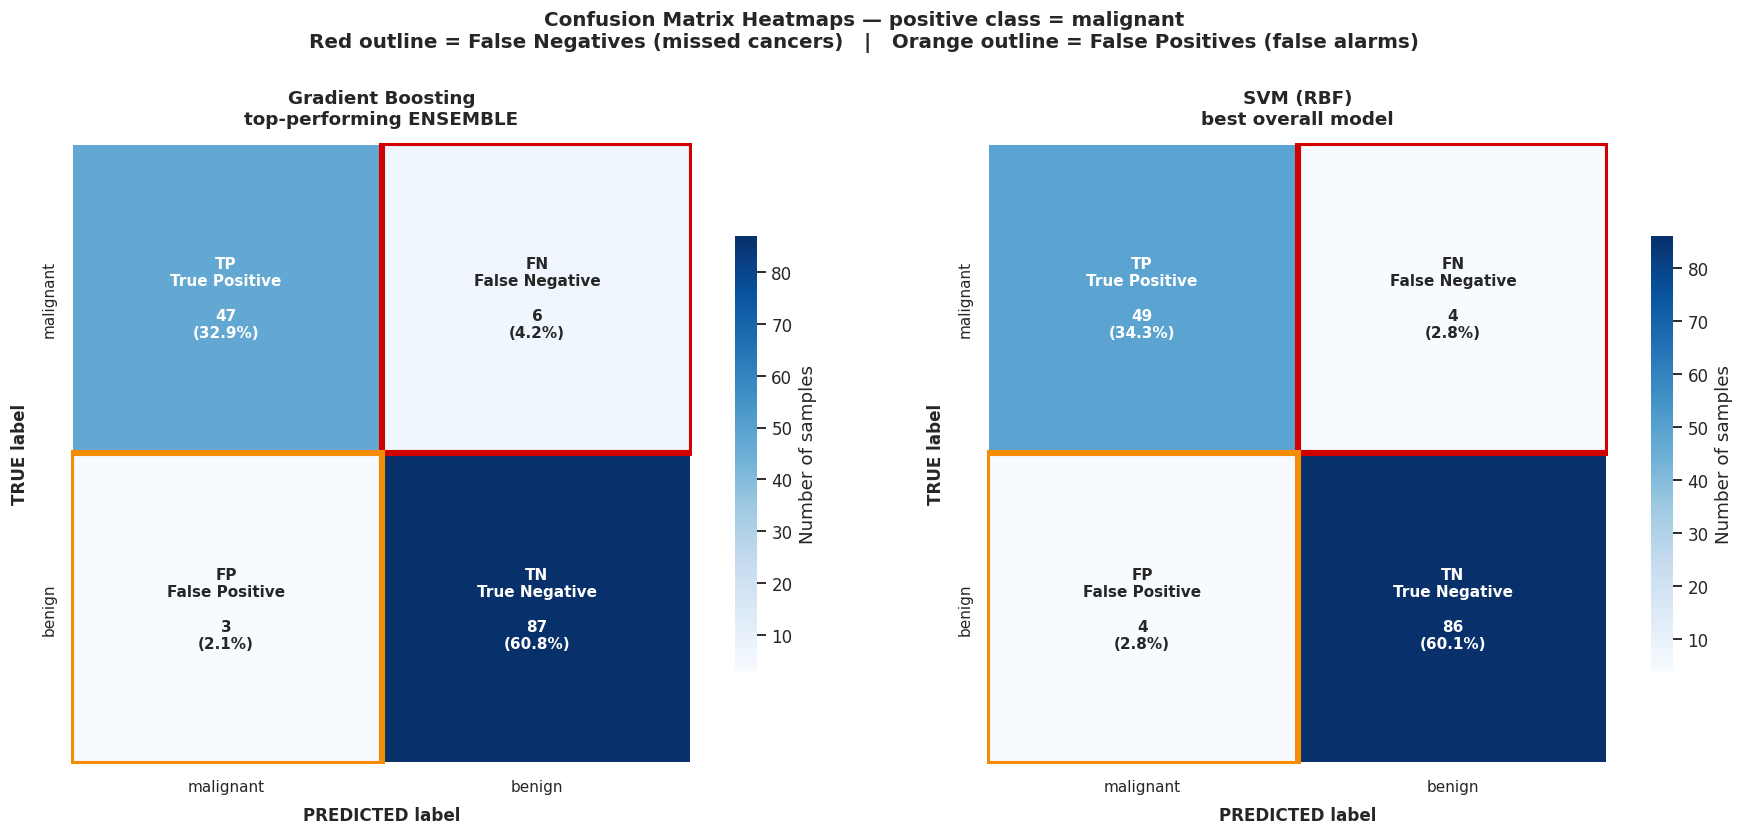

In [ ]:
import matplotlib.patches as patches

# The only ensemble architecture among our three models
ENSEMBLE_MODELS   = ["Gradient Boosting"]
best_ensemble_name = results_df.loc[ENSEMBLE_MODELS].sort_values(
    ["F1-Score", "ROC-AUC"], ascending=False).index[0]

# Plot the required ensemble matrix, plus the overall winner if it differs
models_to_plot = [best_ensemble_name]
if best_model_name != best_ensemble_name:
    models_to_plot.append(best_model_name)


def plot_confusion(ax, model_name, subtitle):
    """Draw an annotated confusion-matrix heatmap for one model on a given axis.

    Rows/cols are ordered [malignant, benign] so that, under our
    'malignant = positive' convention, the quadrants read as TP / FN / FP / TN.
    Returns the (TP, FN, FP, TN) tuple for downstream reporting.
    """
    cm = confusion_matrix(y_test, preds[model_name], labels=[0, 1])

    TP, FN = cm[0, 0], cm[0, 1]   # malignant caught | MISSED CANCER
    FP, TN = cm[1, 0], cm[1, 1]   # false alarm      | benign correctly cleared

    quadrant_labels = np.array([["TP\nTrue Positive",  "FN\nFalse Negative"],
                                ["FP\nFalse Positive", "TN\nTrue Negative"]])
    total = cm.sum()
    annotations = np.empty_like(cm, dtype=object)
    for i in range(2):
        for j in range(2):
            annotations[i, j] = (f"{quadrant_labels[i, j]}\n\n"
                                 f"{cm[i, j]}\n({cm[i, j]/total*100:.1f}%)")

    sns.heatmap(cm, annot=annotations, fmt="", cmap="Blues",
                square=True, linewidths=2.5, linecolor="white",
                cbar_kws={"label": "Number of samples", "shrink": 0.7},
                annot_kws={"fontsize": 10, "fontweight": "bold"},
                xticklabels=["malignant", "benign"],
                yticklabels=["malignant", "benign"], ax=ax)

    # --- Explicitly outline the two ERROR quadrants -----------------------
    for (row, col, colour) in [(0, 1, "#d00000"),    # FN -> red
                               (1, 0, "#f48c06")]:   # FP -> orange
        ax.add_patch(patches.Rectangle((col, row), 1, 1, fill=False,
                                       edgecolor=colour, linewidth=4, zorder=10))

    ax.set_xlabel("PREDICTED label", fontsize=11, fontweight="bold", labelpad=8)
    ax.set_ylabel("TRUE label", fontsize=11, fontweight="bold", labelpad=8)
    ax.set_title(f"{model_name}\n{subtitle}", fontsize=12, fontweight="bold", pad=12)
    ax.tick_params(labelsize=10)
    return TP, FN, FP, TN


fig, axes = plt.subplots(1, len(models_to_plot),
                         figsize=(8.5 * len(models_to_plot), 7))
axes = np.atleast_1d(axes)

quadrants = {}
for ax, name in zip(axes, models_to_plot):
    subtitle = ("top-performing ENSEMBLE" if name == best_ensemble_name
                else "best overall model")
    quadrants[name] = plot_confusion(ax, name, subtitle)

fig.suptitle("Confusion Matrix Heatmaps — positive class = malignant\n"
             "Red outline = False Negatives (missed cancers)   |   "
             "Orange outline = False Positives (false alarms)",
             fontsize=13, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_confusion_matrix.png"))
plt.show()

# Quadrants of the top-performing ensemble, used in the error profile below
TP, FN, FP, TN = quadrants[best_ensemble_name]

In [ ]:
# --- Clinical interpretation of the error profile -------------------------
for name, (tp, fn, fp, tn) in quadrants.items():
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0   # recall on malignant
    specificity = tn / (tn + fp) if (tn + fp) else 0.0   # recall on benign
    ppv         = tp / (tp + fp) if (tp + fp) else 0.0   # precision on malignant
    npv         = tn / (tn + fn) if (tn + fn) else 0.0

    role = ("top-performing ENSEMBLE" if name == best_ensemble_name
            else "best overall model")
    print("=" * 64)
    print(f"ERROR PROFILE — {name}  ({role})")
    print("=" * 64)
    print(f"  True  Positives (malignant caught)      : {tp}")
    print(f"  False Negatives (MISSED CANCERS)        : {fn}   <-- most costly")
    print(f"  False Positives (false alarms)          : {fp}   <-- recoverable")
    print(f"  True  Negatives (benign cleared)        : {tn}")
    print("-" * 64)
    print(f"  Sensitivity / Recall (malignant) : {sensitivity:.4f}")
    print(f"  Specificity          (benign)    : {specificity:.4f}")
    print(f"  PPV / Precision      (malignant) : {ppv:.4f}")
    print(f"  NPV                              : {npv:.4f}")

    if fn == 0:
        print("\n  -> Every malignant case in the test set was correctly identified.")
    else:
        print(f"\n  -> {fn} malignant case(s) missed. In deployment, lowering the decision")
        print("     threshold trades extra false alarms for improved sensitivity.")
    print()

ERROR PROFILE — Gradient Boosting  (top-performing ENSEMBLE)
  True  Positives (malignant caught)      : 47
  False Negatives (MISSED CANCERS)        : 6   <-- most costly
  False Positives (false alarms)          : 3   <-- recoverable
  True  Negatives (benign cleared)        : 87
----------------------------------------------------------------
  Sensitivity / Recall (malignant) : 0.8868
  Specificity          (benign)    : 0.9667
  PPV / Precision      (malignant) : 0.9400
  NPV                              : 0.9355

  -> 6 malignant case(s) missed. In deployment, lowering the decision
     threshold trades extra false alarms for improved sensitivity.

ERROR PROFILE — SVM (RBF)  (best overall model)
  True  Positives (malignant caught)      : 49
  False Negatives (MISSED CANCERS)        : 4   <-- most costly
  False Positives (false alarms)          : 4   <-- recoverable
  True  Negatives (benign cleared)        : 86
----------------------------------------------------------------
  

In [ ]:
# --- Final artefact manifest ----------------------------------------------
print("Saved diagnostic plots:\n")
for fname in sorted(os.listdir(FIG_DIR)):
    size_kb = os.path.getsize(os.path.join(FIG_DIR, fname)) / 1024
    print(f"  {fname:<38} {size_kb:7.1f} KB")

print("\n" + "=" * 60)
print("FINAL RESULTS TABLE")
print("=" * 60)
print(results_df.to_string())
print("=" * 60)
print(f"Best model: {best_model_name}")

Saved diagnostic plots:

  01_feature_selection.png                 201.7 KB
  02_hyperparameter_impact.png             262.4 KB
  03_model_comparison.png                  119.8 KB
  04_confusion_matrix.png                  190.0 KB

FINAL RESULTS TABLE
                   Accuracy  Precision  Recall  F1-Score  ROC-AUC   CV F1
Model                                                                    
Decision Tree        0.9021     0.8305  0.9245    0.8750   0.9372  0.9332
Gradient Boosting    0.9371     0.9400  0.8868    0.9126   0.9868  0.9427
SVM (RBF)            0.9441     0.9245  0.9245    0.9245   0.9916  0.9351
Best model: SVM (RBF)
